# NLP

## Step 1: Importing Libraries

In [1]:

import  pandas #for manipulating data
import re #for helps us find and replace patterns in text
import string #  gives us a ready made list of all punctuation marks like . , ! ? ( ) " '
# ── Import the libraries we need for charts ──────────
# matplotlib is the main chart library in Python
# seaborn makes matplotlib charts look more beautiful
import matplotlib.pyplot as plt
import seaborn as sns

# ── Import the WordCloud library ──────────────────────
from wordcloud import WordCloud

## Step 1a

In [2]:
import pandas as pd

df = pd.read_csv('techjob_descriptions.csv')

# Fix the column name - Title has a trailing space
df.columns = df.columns.str.strip()

print(f"Total job descriptions: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Job titles found:")
print(df['Title'].value_counts())

Total job descriptions: 65
Columns: ['Title', 'Company', 'Location', 'Description', 'Unnamed: 4', 'Unnamed: 5']

Job titles found:
Title
Data Analyst                                                          6
Data Scientist                                                        4
AI Engineer                                                           3
Machine Learning Engineer                                             3
Senior Data Scientist                                                 2
Business Intelligence Analyst                                         2
Senior AI Engineer                                                    2
Revenue Operations Analyst                                            2
Machine Learning Software Development Engineer, AI Ops Integration    1
Analytics Consultant                                                  1
Senior Data Analyst                                                   1
Product Analyst                                                       1

## Step 2 — Explore the Dataset

Before we extract any skills we need to understand 
what our dataset looks like.

We will check:
- Which countries have the most job postings
- Whether any values are missing
- How long the job descriptions are

Longer descriptions give us more skills to extract 
and analyse!

In [3]:
# Check locations
print("=== Locations ===")
print(df['Location'].value_counts())
print()

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print()

# Check average description length
df['desc_length'] = df['Description'].apply(len)
print("=== Description Length ===")
print(f"Average: {df['desc_length'].mean():.0f} characters")
print(f"Shortest: {df['desc_length'].min()} characters")
print(f"Longest: {df['desc_length'].max()} characters")

=== Locations ===
Location
United States                   32
Nigeria                          4
South Africa                     4
Ireland                          4
Morocco                          3
Malaysia                         2
Indonesia                        2
United Kingdom                   2
Canada                           2
Germany                          2
London Area, United Kingdom      1
Dublin                           1
South Korea                      1
India                            1
United Kingdom                   1
Netherlands                      1
Douala                           1
Kenya                            1
Name: count, dtype: int64

=== Missing Values ===
Title           0
Company         0
Location        0
Description     0
Unnamed: 4     65
Unnamed: 5     65
dtype: int64

=== Description Length ===
Average: 394 characters
Shortest: 83 characters
Longest: 2924 characters


## Step 3 — Clean the Text

Raw job descriptions contain a lot of noise:
- UPPERCASE and lowercase versions of the same word
- Punctuation like commas, brackets and full stops
- Common words like "the", "and", "we" that tell us nothing
- Extra spaces and special characters

We need to clean all of this before we can extract 
meaningful skills.

This process is called **text preprocessing** and 
it is the foundation of every NLP project.

In [4]:

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to all descriptions
df['clean_description'] = df['Description'].apply(clean_text)

# Compare before and after
print("=== BEFORE cleaning ===")
print(df['Description'].iloc[0][:200])
print()
print("=== AFTER cleaning ===")
print(df['clean_description'].iloc[0][:200])

=== BEFORE cleaning ===
As part of AI Operations Integration, we have a vision to transform Amazon Operations & Supply Chain into an AI-Native organization by delivering intuitive and differentiated AI solutions that solve e

=== AFTER cleaning ===
as part of ai operations integration we have a vision to transform amazon operations supply chain into an ainative organization by delivering intuitive and differentiated ai solutions that solve endur


## Step 4 — Extract Skills from Job Descriptions

Now we search every job description for specific 
skills that employers mention.

We do this by creating a list of skills we want 
to look for, then checking if each skill appears 
in each job description.

This technique is called **keyword matching** and 
it is the foundation of most real world NLP 
skill extraction systems.

In [5]:
# Define the skills we are looking for
skills_list = [
    # Programming languages
    'python', 'r', 'sql', 'java', 'scala', 
    'javascript',
    
    # Machine learning and AI
    'machine learning', 'deep learning', 
    'natural language processing', 'nlp',
    'computer vision', 'tensorflow', 'pytorch',
    'scikit-learn', 'keras',
    
    # Data and analytics tools
    'power bi', 'tableau', 'excel', 'spark',
    'hadoop', 'airflow',
    
    # Cloud platforms
    'aws', 'azure', 'google cloud', 'gcp',
    
    # Databases
    'postgresql', 'mysql', 'mongodb', 
    'snowflake', 'bigquery',
    
    # Soft skills
    'communication', 'collaboration', 
    'problem solving', 'storytelling',
    
    # Other important skills
    'statistics', 'data visualization', 
    'feature engineering', 'etl', 'api',
    'docker', 'git', 'mlops'
]

# Count how many times each skill appears 
# across ALL job descriptions
skill_counts = {}

for skill in skills_list:
    count = df['clean_description'].str.contains(
        skill, case=False
    ).sum()
    skill_counts[skill] = count

# Convert to a dataframe and sort
skills_df = pd.DataFrame(
    list(skill_counts.items()), 
    columns=['skill', 'count']
)
skills_df = skills_df.sort_values(
    'count', ascending=False
)

print("=== TOP 20 IN-DEMAND SKILLS ===")
print(skills_df.head(20).to_string(index=False))

=== TOP 20 IN-DEMAND SKILLS ===
           skill  count
               r     65
             sql      7
machine learning      7
           scala      6
          python      4
             nlp      4
             api      4
        power bi      3
         tableau      3
   collaboration      3
           mlops      3
         pytorch      2
           excel      2
   deep learning      1
             etl      1
             gcp      1
             git      1
 computer vision      1
           azure      1
             aws      1


## Step 4b — Fix Skill Extraction with Word Boundaries

Our first attempt had a problem — the letter "r" 
was matching inside every word like "for", "our" 
and "career".

We fix this using regex word boundaries (\b) which 
tell Python to only match whole words.

This is a common NLP challenge called the 
**false positive problem** — and fixing it is 
exactly what separates a careful data scientist 
from a careless one!

In [6]:
import re

# Count skills using WHOLE WORD matching only
skill_counts = {}

for skill in skills_list:
    # \b means word boundary - only match whole words
    pattern = r'\b' + re.escape(skill) + r'\b'
    count = df['clean_description'].str.contains(
        pattern, case=False, regex=True
    ).sum()
    skill_counts[skill] = count

# Convert to dataframe and sort
skills_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['skill', 'count']
)
skills_df = skills_df.sort_values(
    'count', ascending=False
)

# Show only skills that appear at least once
skills_df = skills_df[skills_df['count'] > 0]

print("=== TOP IN-DEMAND SKILLS (Fixed) ===")
print(skills_df.to_string(index=False))

=== TOP IN-DEMAND SKILLS (Fixed) ===
              skill  count
   machine learning      7
                sql      6
                nlp      4
             python      4
           power bi      3
            tableau      3
      collaboration      3
              mlops      3
              excel      2
            pytorch      2
                api      1
                etl      1
              azure      1
feature engineering      1
                aws      1
      deep learning      1
    computer vision      1
                gcp      1


## Step 5 — Visualise In-Demand Skills

Now we turn our skill counts into clear 
visual charts.

A good visualisation tells the story instantly 
without needing to read the numbers.

We will create:
1. A bar chart of top skills
2. A word cloud showing all skills visually

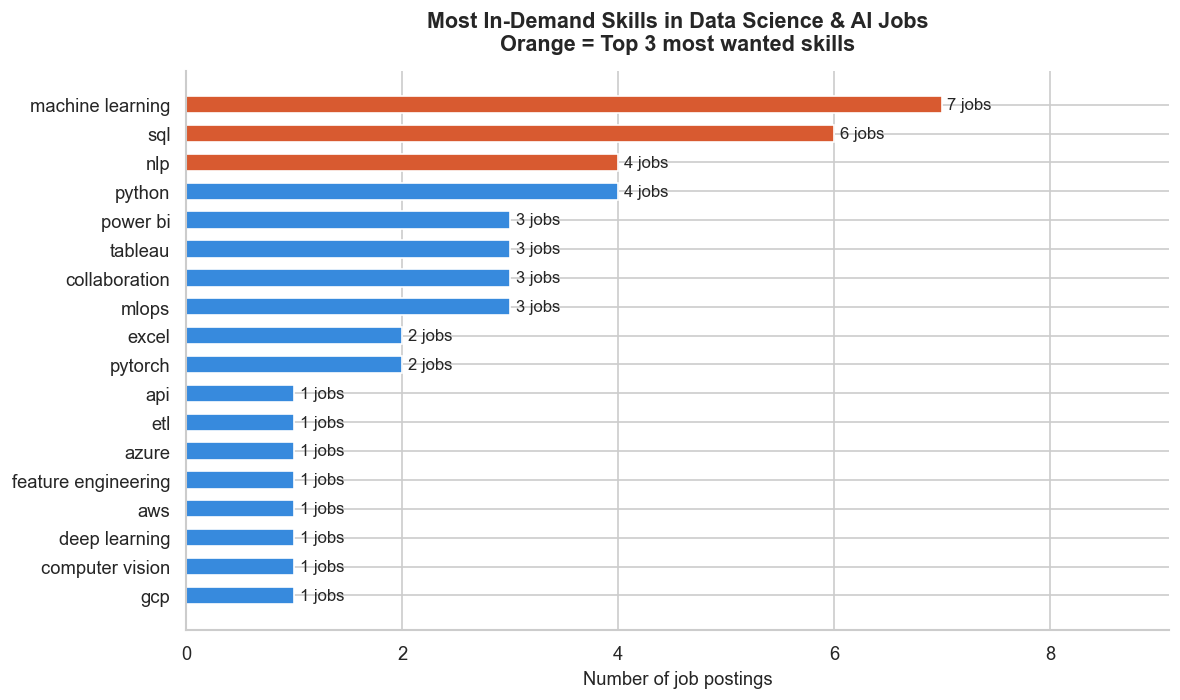

Chart saved!


In [7]:


# ── Set the visual style for ALL charts ──────────────
# whitegrid adds light grid lines in the background
sns.set_theme(style="whitegrid")

# dpi = dots per inch — higher number = sharper image
plt.rcParams['figure.dpi'] = 120

# Remove the top and right border lines from charts
# This makes charts look cleaner and more modern
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Create the chart canvas ───────────────────────────
# fig = the whole figure (like a blank piece of paper)
# ax = the actual chart drawn on that paper
# figsize = width and height of the chart in inches
fig, ax = plt.subplots(figsize=(10, 6))

# ── Set bar colors ────────────────────────────────────
# We want the top 3 skills to be orange (#D85A30)
# and all other skills to be blue (#378ADD)
# i < 3 means: if the position is 0, 1 or 2 (top 3)
# use orange, otherwise use blue
colors = ['#D85A30' if i < 3 else '#378ADD' 
          for i in range(len(skills_df))]

# ── Draw the horizontal bar chart ────────────────────
# ax.barh = horizontal bar chart (barh = bar horizontal)
# skills_df['skill'] = the skill names on the Y axis
# skills_df['count'] = the count numbers on the X axis
# color = our orange/blue colors from above
# height = how thick each bar is (0.6 = 60% of space)
bars = ax.barh(
    skills_df['skill'],   # Y axis — skill names
    skills_df['count'],   # X axis — how many jobs
    color=colors,         # our custom colors
    height=0.6            # bar thickness
)

# ── Add number labels on each bar ────────────────────
# We loop through each bar and its value together
# bar = the actual bar shape
# val = the count number for that bar
for bar, val in zip(bars, skills_df['count']):
    ax.text(
        # X position: end of bar + small gap
        bar.get_width() + 0.05,
        
        # Y position: middle of the bar
        bar.get_y() + bar.get_height()/2,
        
        # The text to show — e.g. "5 jobs"
        f'{val} jobs',
        
        # va = vertical alignment — center the text
        va='center',
        
        # Font size of the label
        fontsize=10,
        
        # fontweight 500 = slightly bold
        fontweight='500'
    )

# ── Add axis labels and title ─────────────────────────
# Label for the X axis (bottom)
ax.set_xlabel("Number of job postings", fontsize=11)

# Title at the top of the chart
# \n means new line — splits title into 2 lines
ax.set_title(
    "Most In-Demand Skills in Data Science & AI Jobs\n"
    "Orange = Top 3 most wanted skills",
    fontsize=13,
    fontweight='bold',
    pad=12  # pad = space between title and chart
)

# ── Set X axis limit ──────────────────────────────────
# We make the X axis a bit wider than the longest bar
# so the labels on the right do not get cut off
# max() finds the biggest count, * 1.3 adds 30% space
ax.set_xlim(0, skills_df['count'].max() * 1.3)

# ── Flip the Y axis ───────────────────────────────────
# By default bars go from bottom to top
# invert_yaxis() flips it so the TOP skill
# appears at the TOP of the chart
ax.invert_yaxis()

# ── Final layout and save ─────────────────────────────
# tight_layout() automatically fixes spacing
# so nothing gets cut off at the edges
plt.tight_layout()

# Save the chart as a PNG image file
# bbox_inches='tight' makes sure nothing is cut off
plt.savefig('chart1_top_skills.png', bbox_inches='tight')

# Display the chart in your notebook
plt.show()

print("Chart saved!")

## Step 6 — Word Cloud Visualisation

A word cloud shows all skills visually —
the bigger the word, the more times it 
appears in job descriptions.

It is a powerful way to communicate findings
to a non-technical audience instantly.

Skills dictionary:
{'machine learning': 7, 'sql': 6, 'nlp': 4, 'python': 4, 'power bi': 3, 'tableau': 3, 'collaboration': 3, 'mlops': 3, 'excel': 2, 'pytorch': 2, 'api': 1, 'etl': 1, 'azure': 1, 'feature engineering': 1, 'aws': 1, 'deep learning': 1, 'computer vision': 1, 'gcp': 1}


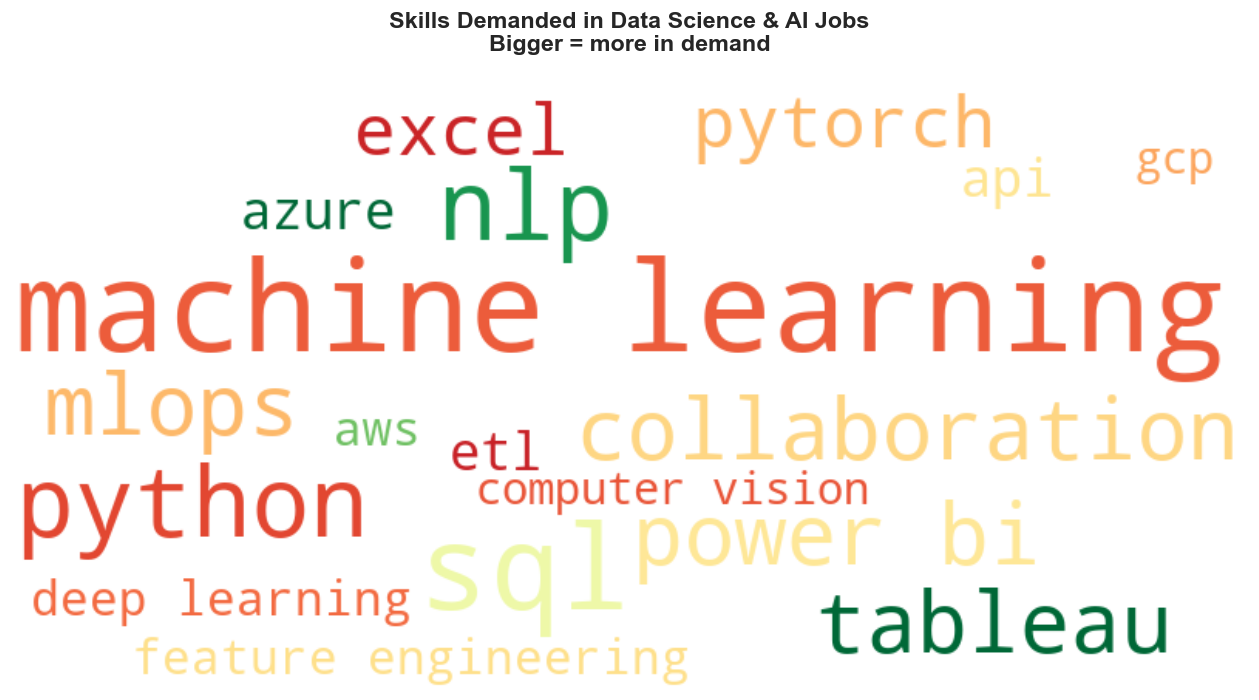

Word cloud saved!


In [8]:

# ── Create a dictionary of skill counts ──────────────
# WordCloud needs a dictionary where:
# key = the word (skill name)
# value = how important/big it should be (count)
skill_dict = dict(zip(
    skills_df['skill'],   # skill names
    skills_df['count']    # their counts
))

print("Skills dictionary:")
print(skill_dict)

# ── Generate the word cloud ───────────────────────────
# width and height = size of the image in pixels
# background_color = colour behind the words
# colormap = colour scheme for the words
# 'RdYlGn' goes from Red (small) to Green (large)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='RdYlGn',
    
    # min_font_size = smallest word size
    min_font_size=14,
    
    # max_font_size = biggest word size
    max_font_size=120
).generate_from_frequencies(skill_dict)

# ── Display the word cloud ────────────────────────────
# Create a figure that is 12 inches wide and 6 tall
fig, ax = plt.subplots(figsize=(12, 6))

# imshow = image show — displays the word cloud
# interpolation='bilinear' makes edges smooth
ax.imshow(wordcloud, interpolation='bilinear')

# Turn off the axis lines and numbers
# They do not make sense for a word cloud
ax.axis('off')

# Add a title above the word cloud
ax.set_title(
    'Skills Demanded in Data Science & AI Jobs\n'
    'Bigger = more in demand',
    fontsize=14,
    fontweight='bold',
    pad=12
)

# Save and show
plt.tight_layout()
plt.savefig('chart2_wordcloud.png', bbox_inches='tight')
plt.show()

print("Word cloud saved!")

## Step 7 — Africa vs Global Skills Comparison

We now split our dataset into two groups:
- African job postings (Douala, Morocco, 
  South Africa)
- Global job postings (US, UK, Europe, Asia)

This comparison answers a question no one 
else in your cohort is asking:

"Are African employers looking for the same 
skills as global employers — or different ones?"


In [ ]:
# Define African locations
african_locations = ['Douala', 'Morocco', 'South Africa','Nigeria  ','Kenya']

# Split into Africa and Global
africa_df = df[
    df['Location'].str.contains(
        '|'.join(african_locations), 
        case=False, na=False
    )
]

# ~ means NOT — everything outside Africa
global_df = df[
    ~df['Location'].str.contains(
        '|'.join(african_locations),
        case=False, na=False
    )
]

print(f"African jobs: {len(africa_df)}")
print(f"Global jobs:  {len(global_df)}")
print()
print("African locations:")
print(africa_df['Location'].value_counts())

African jobs: 8
Global jobs:  57

African locations:
Location
South Africa    4
Morocco         3
Douala          1
Name: count, dtype: int64


## Step 7b — Compare Skills: Africa vs Global

We extract the most demanded skills separately 
for African and Global job postings and compare 
them side by side.

In [10]:
# Function to count skills in any dataframe
def count_skills(data):
    counts = {}
    for skill in skills_list:
        pattern = r'\b' + re.escape(skill) + r'\b'
        count = data['clean_description'].str.contains(
            pattern, case=False, regex=True
        ).sum()
        counts[skill] = count
    return pd.DataFrame(
        list(counts.items()),
        columns=['skill', 'count']
    ).sort_values('count', ascending=False)

# Count skills for each group
africa_skills = count_skills(africa_df)
global_skills = count_skills(global_df)

# Show only skills that appear at least once
africa_skills = africa_skills[africa_skills['count'] > 0]
global_skills = global_skills[global_skills['count'] > 0]

print("=== TOP SKILLS IN AFRICA ===")
print(africa_skills.head(10).to_string(index=False))
print()
print("=== TOP SKILLS GLOBALLY ===")
print(global_skills.head(10).to_string(index=False))

=== TOP SKILLS IN AFRICA ===
           skill  count
machine learning      2
             nlp      2
             sql      1
          python      1
   deep learning      1
             gcp      1
             aws      1
           azure      1
        power bi      1
         tableau      1

=== TOP SKILLS GLOBALLY ===
           skill  count
machine learning      5
             sql      5
          python      3
   collaboration      3
        power bi      2
             nlp      2
           excel      2
         tableau      2
         pytorch      2
           mlops      2


In [11]:
# Print all African job descriptions to see what is inside
for i, row in africa_df.iterrows():
    print(f"=== {row['Title']} | {row['Location']} ===")
    print(row['clean_description'])
    print()

=== Data Analyst | Douala ===
acquiring data from primary or secondary data sources and maintaining databases interpreting data analyzing results using statistical techniques developing and implementing data analyses data collection systems and other strategies that optimize statistical efficiency and quality provide quality assurance of imported data working with quality assurance analysts if necessary processing confidential data and information according to guidelines helping develops reports and analyses managing and designing the reporting environment including data sources security and metadata training endusers on new reports and dashboards supporting initiatives for data integrity and normalization

=== AI Engineer | Morocco ===
manages the build of ai orchestrators and develops llmbased applications using rag and toolcalling

=== Technical Business Analyst | South Africa ===
collaborate with technical teams to translate business requirements into technical artifacts and soluti